# CIFAR-100 Classification Final Model

In [1]:
# 1. Setup
import os, sys, torch

REPO_URL = "https://github.com/NatanSisoev/CIFAR-100-Classification.git"
REPO_DIR = "/content/CIFAR-100-Classification/"
SAVE_PATH = REPO_DIR + "artifacts/smallresnet_best.pth"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

!pip install -q loguru

Already up to date.


In [2]:
# 2. Imports
from data import get_cifar100_loaders
from models import SmallResNet, get_device, count_parameters

In [3]:
# 3. Device & data
device = get_device()
train_loader, test_loader = get_cifar100_loaders()

2026-04-04 09:21:55.195 | WARNING  | models.utils:get_device:48 - using device: cpu
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
2026-04-04 09:21:58.250 | SUCCESS  | data.datasets:get_cifar100_loaders:19 - Succesfully loaded train loade

In [ ]:
# 4. Get model
state = SmallResNet.restore(device, save_path=SAVE_PATH)

2026-04-04 09:21:58.358 | INFO     | models.smallresnet:restore:172 - Restored SmallResNet from '/content/CIFAR-100-Classification/artifacts/smallresnet_best.pth' (epoch 294, best acc 52.95%)


In [6]:
# 5. Evaluate
from sklearn.metrics import f1_score

model = state["model"] if isinstance(state, dict) else state
model.eval()

criterion = torch.nn.CrossEntropyLoss()

k_values = range(1, 21)

correct_topk = {k: 0 for k in k_values}
total = 0
test_loss = 0.0

all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)

        # Top-k accuracy
        maxk = max(k_values)
        _, pred_topk = outputs.topk(maxk, dim=1, largest=True, sorted=True)
        pred_topk = pred_topk.t()

        for k in k_values:
            correct_topk[k] += pred_topk[:k].eq(targets.view(1, -1)).sum().item()

        # For F1
        _, preds = outputs.max(1)
        all_preds.append(preds.cpu())
        all_targets.append(targets.cpu())

        total += targets.size(0)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [7]:
# Aggregate
avg_loss = test_loss / total
topk_acc = {k: correct_topk[k] / total for k in k_values}

all_preds_catted = torch.cat(all_preds)
all_targets_catted = torch.cat(all_targets)

# F1 score (macro): average F1 of each class
f1_macro = f1_score(all_targets_catted, all_preds_catted, average="macro")

# d
params = count_parameters(model) / 100_000
d = (params ** 2 + (1 - topk_acc[1]) ** 2) ** (1 / 2)

print(f"{'Metric':<19} {'Value':>10}")
print("-" * 32)
print(f"{'Test Loss':<20} {avg_loss:>10.4f}")
for k in k_values[:5]:
    print(f"Top-{k} Accuracy{'':<6} {topk_acc[k]*100:>9.2f}%")
print(f"{'F1 Score (macro)':<20} {f1_macro:>10.4f}")
print(f"{'d metric':<20} {d:>10.4f}")

Metric                   Value
--------------------------------
Test Loss                1.8532
Top-1 Accuracy           52.95%
Top-2 Accuracy           67.30%
Top-3 Accuracy           75.07%
Top-4 Accuracy           79.84%
Top-5 Accuracy           83.25%
F1 Score (macro)         0.5139
d metric                 1.1588


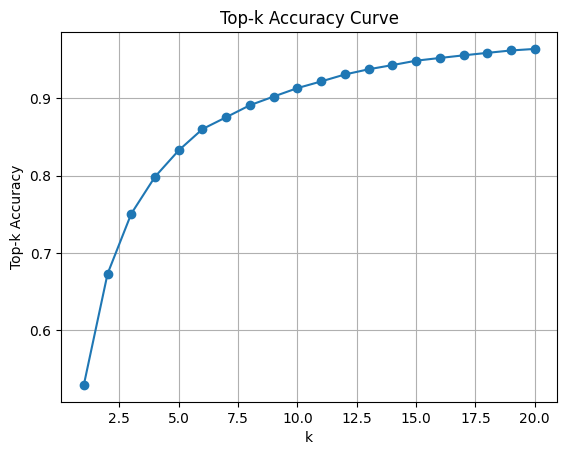

In [8]:
import matplotlib.pyplot as plt

k_vals = list(topk_acc.keys())
acc_vals = [topk_acc[k] for k in k_vals]

plt.plot(k_vals, acc_vals, marker='o')
plt.xlabel("k")
plt.ylabel("Top-k Accuracy")
plt.title("Top-k Accuracy Curve")
plt.grid(True)
plt.show()